In [1]:
import geopandas as gpd
import sys
from pathlib import Path
path = Path().cwd().parent / "src" #to add the src directory to the path regognized by Python
sys.path.append(str(path))
import methods_two_point_correlation as mtpc
import methods_epidemics as mepi
import save_load_pickle as slp
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import distance
import matplotlib.pyplot as plt
import sklearn.cluster as sk
import sys
from sklearn.metrics import silhouette_score
from shapely.geometry import Polygon,Point
from scipy.stats import entropy
import networkx as nx
import EoN
from scipy.stats import ttest_ind

# Parameters

In [2]:
#set paths
path = Path().cwd().parent
sys.path.append(str(path))
data_dir = path/"data/cities"
map_dir = path/"data/map"
data_city = data_dir / "cities"
plot_dir = path/"out/plot_fitted_parameters/"

In [3]:
name = "Belgium" #name of country
nbins=30 # number of bins to make for every binning operation
file = path /Path(f"out/fitted_parameters_SP/{name}")
#file = out_dir / f"1_5_7000_3__100000.0_log_{nbins}" #name of dataset

diminish_radius = 1 # multiplication factor for the maximum radius, 
#to be lowered if the SP does not fit inside the considered border quick enough

N_run= 3 # number of random catalog generated for computing the 2PCF, needs to be the same as in the plotted data
size= 3000 #number of points each random catalog has
erase_nodes = False

In [15]:
#Load the polygon file for border
path_border = Path.cwd() / map_dir / f"{name}.geojson"
gdf_edge = gpd.read_file(path_border)
path_city = data_dir / f"{name}_cities.csv" #Path of the cities 
gdf_city = mtpc.load_df_to_gdf(path_city,1) # Geopandas of the dataset


#load the results store in file
dico_results = slp.load_results(file)
r_edges = dico_results["r_edges"] #binning of distance for 2pcf
gamma, r0 = dico_results["fit_SP"] #fitted gamma and R0
l_xi = dico_results["xi"] # 2pcf
country_distribution = dico_results["distance_distribution"] #distance distribution
l_cluster = dico_results["clustering"] #5 best cluster value obtained with the silhouette score
N = dico_results["number_points"] #number of point sin the dataset
crs = mtpc.crs_selector(name) #cooridnate reference system associated with the datset
gdf_edge = gdf_edge.to_crs(crs) # Polygon of the border of the country
gdf_projected = gdf_city.to_crs(crs)

save_dist = dico_results['euclidean_distance_generated_empirical']
save_L = dico_results['list_L_generated']
save_random = dico_results['lsit_number_random_generated']
l_cluster = dico_results['list_l_cluster']
R = 0.5*gdf_edge.length[0]/(2*np.pi)*diminish_radius # radius max
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]

rmin= np.min(r_edges)
rmax= np.max(r_edges)
k = N_run
scale="log"

In [16]:
eta**L/random_point

0.32904884318766064

In [17]:
eta**L

256

In [18]:
len(gdf_projected)

820

In [19]:
print("gamma", gamma)
print("fractal dimension",np.log(eta)/np.log(l))
print("l = ", l)
print("L = ", L)

gamma 0.6724818139619436
fractal dimension 1.3275181860380565
l =  1.685627024211333
L =  8


In [20]:
np.sqrt(np.diag(dico_results["covariance_fit"]))

array([1.06122379e-01, 5.08884924e+02])

In [21]:
def check_inside(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles that fit the border defined by gdf_edge
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
    """
    position,point_outside = soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    while len(point_outside) >= 1: #as long as not all the points fit hte border redo
        #print("Entering the loop")
        position,point_outside=soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    return position


def soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
        points_outside: count the number of points that lie outside of the border as defined by gdf_edge
    """
    position = gdf_edge.centroid.get_coordinates().to_numpy()
    final_position = []
    rng = np.random.default_rng()
    for i in range(L):
        l_pos = []
        for x,y in position:
            r = (R/(lamb**i))*np.random.uniform(low=0, high=1, size=eta)  # radius
            theta = np.random.uniform(low=0, high=2*np.pi, size=eta)  # angle
            l_x_rand = [r[i] * np.cos(theta[i]) for i in range(eta)]
            l_y_rand = [r[i] * np.sin(theta[i]) for i in range(eta)]
            l_point = [Point((x_rand,y_rand)) for x_rand,y_rand in zip(l_x_rand,l_y_rand)] 
            #l_random = (R/(lamb**i))*rng.random((eta,2))
            for x_rand,y_rand in zip(l_x_rand,l_y_rand):
                #s = geopandas.GeoSeries(point)
                l_pos.append((x-x_rand,y-y_rand))
        position = np.copy(l_pos)
        final_position = final_position + l_pos
    if type(erase_nodes) == int and erase_nodes >=0:
        print("enter erase")
        position = list(position)
        while erase_nodes != 0:
            index = rng.choice(range(len(position)))
            position.pop(index)
            erase_nodes -= 1
    position = np.array(position)
    #l_point = [Point(position[i]) for i in range(len(position))]
    s = gpd.GeoDataFrame(position, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    points_with_join = gpd.sjoin(s, gdf_edge, how="left", predicate="within")
    points_with_join['is_inside'] = points_with_join['index_right'].notna()
    point_outside = points_with_join[points_with_join["is_inside"] == False]
    return position,point_outside

def plot_two_2pcf(r_edges,l_xi,l_xi_SP):
    fig, ax = plt.subplots()
    sns.set(style="whitegrid")
    xi = np.mean(l_xi,axis=0)
    error = np.std(l_xi,axis=0)
    xi_SP = np.mean(l_xi_SP,axis=0)
    error = np.std(l_xi,axis=0)
    if len(xi) != len(r_edges): #when we choose a rmax define by user the code put an extra category above
        xi = xi[0:-1]
        error = error[0:-1]
        xi_SP = xi_SP[0:-1]
    color = sns.color_palette("viridis")[0]
    color_SP = sns.color_palette("viridis")[1]
    r_edges = r_edges[1:]
    xi = xi[1:]
    xi_SP = xi_SP[1:]
    error = error[1:]
    end = np.zeros([1])
    end[0] = 1.1*r_edges[-1]
    r_edges_zero = np.concatenate((r_edges,end))
    width = np.diff(r_edges_zero) #need to find a way to encode properly the first alignement
    ax.bar(r_edges,xi,width=width,align="center",edgecolor="black",color=color,alpha=0.5,label=f"{name}")
    ax.bar(r_edges,xi_SP,width=width,align="center",edgecolor="black",color=color_SP,alpha=0.5,label="SP")
    plt.errorbar(r_edges, xi, yerr=error, fmt="o", color="r",ms=1)
    title = "2 points correlation function "+name
    plt.title(title)
    plt.ylabel(r"$\xi(r)$")
    plt.xlabel(r"$r$ (meters)")
    plt.xscale("log")
    #plt.yscale("log")
    plt.legend()
    #plt.savefig(plot_dir / title, format="png",transparent=True)
    plt.show()

# Generate one instance of the model to check

In [28]:
def generate_a_SP_plus_random(l,eta,L,R,random_point,gdf_edge,crs,N,erase_nodes=0):
    position = check_inside(l,eta,L,R,gdf_edge,erase_nodes)
    d = {}
    d["x"] = position.T[0]
    d["y"] = position.T[1]
    #df = pd.DataFrame((position))
    gdf = gpd.GeoDataFrame(
          d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    gdf_random_square = gdf_edge.sample_points(random_point)
    gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
    gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
    #print(len(gdf))
    l_index = [i for i in range(len(gdf))]
    to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
    gdf.drop(to_drop, inplace=True)
    return gdf

def select_model_best_fit(n_try,l,eta,L,R,random_point,gdf_edge,crs,N,l_xi):
    save_dist = []
    dist_between_distribution = 1000
    for j in range(n_try): #for the given paraemters launch several try, to plot the best fit and see the value of the cost function
        gdf_generated = generate_a_SP_plus_random(l,eta,L,R,random_point,gdf_edge,crs,N,erase_nodes=0)
        r_edge,l_xi_SP = mtpc.PCF_with_variance(gdf_generated,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
        if np.linalg.norm(np.mean(l_xi_SP,axis=0)-np.mean(l_xi,axis=0)) < dist_between_distribution: # euclidean cost function
            dist_between_distribution = np.linalg.norm(np.mean(l_xi_SP,axis=0)-np.mean(l_xi,axis=0))
            print("distance obtained", dist_between_distribution)
            gdf_choice = gdf_generated
    return gdf_choice,dist_between_distribution

def select_model_best_KL(n_try,l,eta,L,R,random_point,gdf_edge,crs,N,l_xi):
    save_dist = []
    dist_between_distribution = 1000
    mean_xi = np.mean(l_xi,axis=0)
    distrib_xi = mean_xi/np.sum(mean_xi)
    KL_distro = 1e99
    for j in range(n_try): #for the given paraemters launch several try, to plot the best fit and see the value of the cost function
        gdf_generated = generate_a_SP_plus_random(l,eta,L,R,random_point,gdf_edge,crs,N,erase_nodes=0)
        r_edge,l_xi_SP = mtpc.PCF_with_variance(gdf_generated,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
        mean_SP = np.mean(l_xi_SP,axis=0)
        distrib_SP = mean_SP/np.sum(mean_SP)
        KL = entropy(distrib_xi,distrib_SP)
        if KL < KL_distro: # euclidean cost function
            KL = KL_distro
            gdf_choice = gdf_generated
    return gdf_choice

def compute_mobility_from_radiation(pop_distribution,gdf):
    coord = gdf.get_coordinates().to_numpy()
    distance_matrix = distance.cdist(coord,coord).astype(np.int32)
    mobility_matrix = mepi.multiprocessing_radiation_model(pop_distribution,distance_matrix)
    return mobility_matrix

def save_file(gdf,mobility_matrix,path):
    dico = {}
    dico["gdf"] = gdf
    dico["mobility"] = mobility_matrix
    slp.save_results(path,dico)
    return 0
        

In [29]:
n_generated = 10
n_try = 1
pop_per_node = 1000
pop_distribution = [pop_per_node for i in range(N)]


In [30]:
%time mobility_data = compute_mobility_from_radiation(pop_distribution,gdf_projected)
save_dir =  Path.cwd().parent /Path(f"out/mobility_matrix/{name}/network_data.dat")
save_file(gdf_projected,mobility_data,save_dir)

CPU times: user 80.1 ms, sys: 127 ms, total: 207 ms
Wall time: 9.84 s


0

In [38]:
for i in range(n_generated):
    gdf_projected_random= mtpc.generate_random_point(gdf_edge,N,crs,check_gpd=True)
    mobility_random=compute_mobility_from_radiation(pop_distribution,gdf_projected_random)
    save_dir_random =  Path.cwd().parent /Path(f"out/mobility_matrix/{name}/random/network_random{i}.dat")
    save_file(gdf_projected_random,mobility_random,save_dir_random)
    print("random",i)
    gdf_generated,dist_betweem_distribution=select_model_best_fit(n_try,l,eta,L,R,random_point,gdf_edge,crs,N,l_xi)
    mobility_generated=compute_mobility_from_radiation(pop_distribution,gdf_generated)
    save_dir_generated =  Path.cwd().parent /Path(f"out/mobility_matrix/{name}/generated/network_generated{i}.dat")
    save_file(gdf_generated,mobility_generated,save_dir_generated)
    print("generated",i)
    

random 0
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
enter erase
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 274551
min DD 35
maxRR 288027
minRR 25
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 274551
min DD 35
maxRR 285045
minRR 37
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 274551
min DD 35
maxRR 289074
minRR 34
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
distance obtained 1.1430866025099224
generated 0
random 1
enter erase
enter erase
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284787
min DD 133
maxRR 288398
minRR 23
rmin,rmax= 3579.20107023849

In [13]:
len(gdf_generated)-N

0

In [14]:
dist_betweem_distribution

0.6478673387903059

0
1
rmax  100000.0
rmin 2137.414330263022
max DD 336567
min DD 43
maxRR 338987
minRR 17
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 336567
min DD 43
maxRR 338405
minRR 17
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 336567
min DD 43
maxRR 337872
minRR 8
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


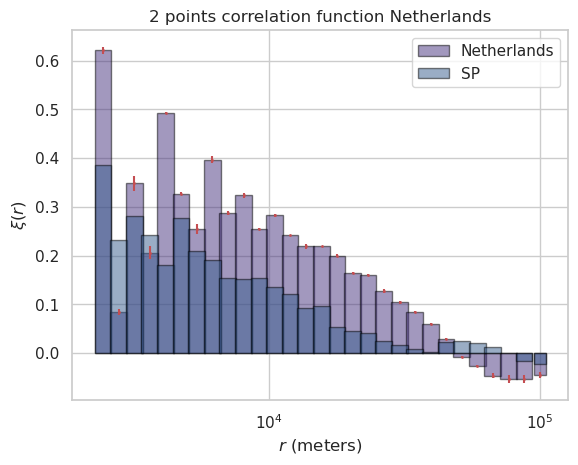

In [25]:
position_genrated = gdf_generated.get_coordinates().values
r_edge,l_xi_SP = mtpc.PCF_with_variance(gdf_generated,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
plot_two_2pcf(r_edges,l_xi,l_xi_SP)

In [16]:
gdf_projected_random= mtpc.generate_random_point(gdf_edge,N,crs,check_gpd=True)

0
1
rmax  100000.0
rmin 2137.414330263022
max DD 332653
min DD 73
maxRR 337909
minRR 20
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 332653
min DD 73
maxRR 338657
minRR 4
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 332653
min DD 73
maxRR 336872
minRR 19
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


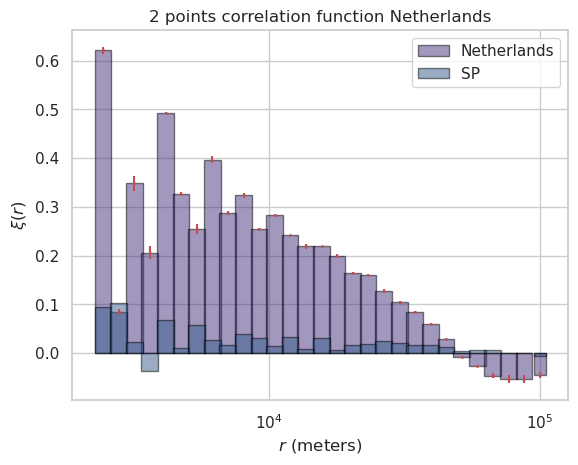

In [17]:
r_edge,l_xi_random = mtpc.PCF_with_variance(gdf_projected_random,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
plot_two_2pcf(r_edges,l_xi,l_xi_random)

In [18]:
len(gdf_projected_random.explode())

2535

In [19]:
len(gdf_generated)

2535

In [20]:
len(gdf_projected)

2535

# Create the branching rule i.e. the radiation model

In [26]:
pop_per_node = 1000
pop_distribution = [pop_per_node for i in range(N)]
coord_random = gdf_projected_random.get_coordinates().to_numpy()
distance_matrix_random = distance.cdist(coord_random,coord_random).astype(np.int32)#np.triu(distance.cdist(coord_data,coord_data))

coord_generated = gdf_generated.get_coordinates().to_numpy()
distance_matrix_generated = distance.cdist(coord_generated,coord_generated).astype(np.int32)#np.triu(distance.cdist(coord_data,coord_data))

coord_data = gdf_projected.get_coordinates().to_numpy() # good order of the indices associated with cities checked
distance_matrix_data = distance.cdist(coord_data,coord_data).astype(np.int32)


In [22]:
np.sum(mobility_data)

NameError: name 'mobility_data' is not defined

In [ ]:
np.sum(mobility_random)

In [ ]:
np.sum(mobility_generated)

In [27]:
sum_distance_random = np.sum(np.triu(distance_matrix_random))
sum_distance_data = np.sum(np.triu(distance_matrix_data))
sum_distance_generated = np.sum(np.triu(distance_matrix_generated))
print("total distanc random",np.sum(np.triu(distance_matrix_random)))
print("total distance data",np.sum(np.triu(distance_matrix_data)))
print("total distance generated:",np.sum(np.triu(distance_matrix_generated)))

total distanc random 366304407876
total distance data 380637370736
total distance generated: 340419608990


In [28]:
sum_distance_random/sum_distance_data

0.9623448353684091

In [29]:
sum_distance_generated/sum_distance_data

0.8943410058023599

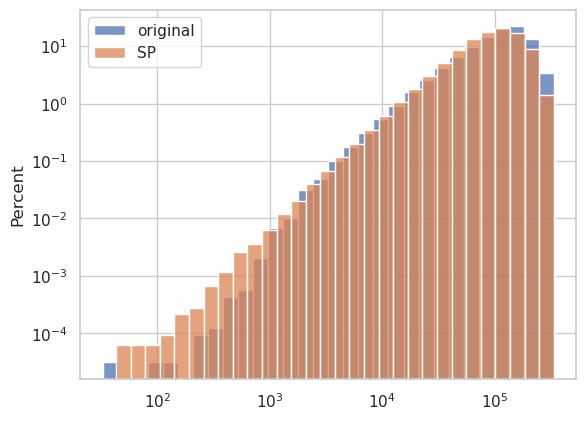

In [30]:
stat="percent"
sns.histplot(np.ravel(np.triu(distance_matrix_data)),bins=nbins,stat=stat,label="original",legend=True,log_scale=True)
sns.histplot(np.ravel(np.triu(distance_matrix_generated)),bins=nbins,stat=stat,label="SP",legend=True,log_scale=True)
#sns.histplot(np.ravel(distance_matrix_random),bins=nbins,stat="density",label="random",legend=True,log_scale=True)
plt.yscale("log")
plt.legend()
plt.show()

In [31]:
np.max(distance_matrix_generated)

336567

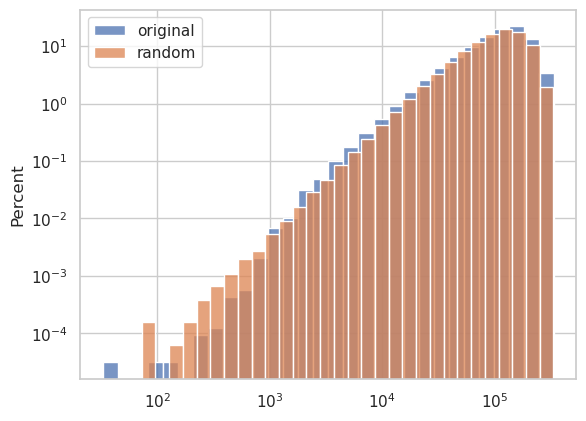

In [32]:
stat="percent"
sns.histplot(np.ravel(distance_matrix_data),bins=nbins,stat=stat,label="original",legend=True,log_scale=True)
#sns.histplot(np.ravel(distance_matrix_generated),bins=nbins,stat="density",label="SP",legend=True,log_scale=True)
sns.histplot(np.ravel(distance_matrix_random),bins=nbins,stat=stat,label="random",legend=True,log_scale=True)
plt.yscale("log")
plt.legend()
plt.show()

In [33]:
mobility_random = mepi.multiprocessing_radiation_model(pop_distribution,distance_matrix_random)

In [34]:
%time mobility_data = mepi.multiprocessing_radiation_model(pop_distribution,distance_matrix_data)

CPU times: user 993 ms, sys: 1.31 s, total: 2.3 s
Wall time: 7min 18s


In [35]:
mobility_generated = mepi.multiprocessing_radiation_model(pop_distribution,distance_matrix_generated)

In [36]:
save_dir =  Path.cwd().parent /Path(f"out/mobility_matrix/{name}.dat")
dico_mobility = {}
dico_mobility["random"] = mobility_random
dico_mobility["data"] = mobility_data
dico_mobility["generated"] = mobility_generated
slp.save_results(save_dir,dico_mobility)

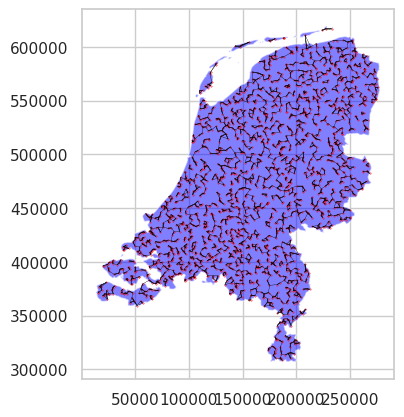

In [37]:
def display_map_mobility(gdf,gdf_edge,mobility_matrix,position,threshold):
    mask = (mobility_matrix >=threshold)
    width =  np.where(mask,mobility_matrix,0)
    width = np.array([width[i] for i in range(len(width))])
    fig,ax = plt.subplots()
    #squares_gdf.plot(ax=ax)
    gdf_edge.plot(ax=ax,color="blue",alpha=0.5)
    gdf.plot(ax=ax,color="red",markersize=0.1)
    for i in range(len(position)):
     for j in range(len(position)):
         if i != j and width[i,j] !=0 and width[i,j] > width[j,i]:
            point1 = [position[i][0],position[i][1]]
            point2 = [position[j][0]-position[i][0],position[j][1]-position[i][1]]
            ax.arrow(point1[0], point1[1],point2[0],point2[1],linestyle="-",linewidth= width[i,j] ,head_width=0.01,head_length=0.02,length_includes_head=True,edgecolor='black',alpha=0.75)
    plt.show()
    
threshold = 0.1
display_map_mobility(gdf_projected_random,gdf_edge,mobility_random,coord_random,threshold)

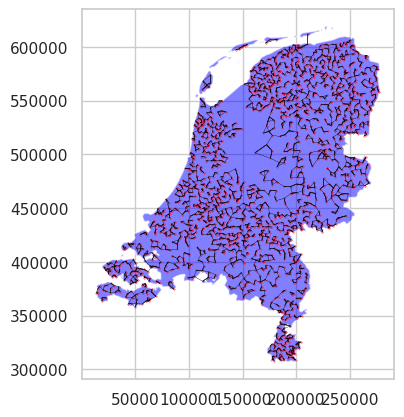

In [38]:
display_map_mobility(gdf_projected,gdf_edge,mobility_data,coord_data,threshold)

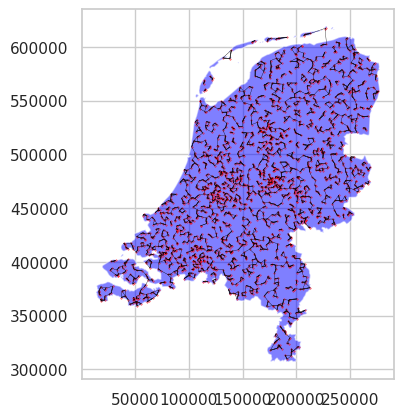

In [39]:
display_map_mobility(gdf_generated,gdf_edge,mobility_generated,coord_generated,threshold)

# Run the epidemics on the networks

In [40]:
G_random = nx.DiGraph(mobility_random)

In [41]:
G_data = nx.DiGraph(mobility_data)

In [42]:
G_generated = nx.DiGraph(mobility_generated)

In [43]:
strength_data = dict(G_data.degree(weight="weight"))
avg_strength_data = np.sum(list(strength_data.values())) / len(G_data)
print("avg strength data:",avg_strength_data)
strength_random = dict(G_random.degree(weight="weight"))
avg_strength_random = np.sum(list(strength_random.values())) / len(G_random)
print("avg strength random:",avg_strength_random)
strength_generated= dict(G_generated.degree(weight="weight"))
avg_strength_generated = np.sum(list(strength_generated.values())) / len(G_generated)
print("avg strength generated:",avg_strength_generated)

avg strength data: 2.0
avg strength random: 2.0
avg strength generated: 2.0


In [44]:
mobility_random[0][3]-mobility_random[3][0]

-0.009924550665678274

In [ ]:
distance_matrix_random

In [45]:
def run_SIR_epidemics(G,tau,gamma,rho,tmax,transmission_weight,count,report_times):
    sums=0*report_times
    sums_R = 0*report_times
    l_R = []
    for i in range(count):
        t, S, I,R = EoN.fast_SIR(G,tau,gamma,rho=rho,transmission_weight=transmission_weigth)
        subsampled_I = EoN.subsample(report_times,t,I)
        subsampled_R = EoN.subsample(report_times,t,R)
        sums_R += subsampled_R
        sums += subsampled_I
        l_R.append(R[-1])
    ave = sums/count
    ave_R = sums_R/count
    return ave,ave_R,l_R

In [46]:
tau = 0.2
gamma = 0.1
rho = 0.05 #initial fraction of infected 
tmax = 150
transmission_weigth = "weight"
return_full_data = False # return the time series of all node if True
count = 200
report_times = np.linspace(0,tmax,10)

In [47]:
ave_I_rand,ave_R_rand,l_R_random=run_SIR_epidemics(G_random,tau,gamma,rho,tmax,transmission_weigth,count,report_times)

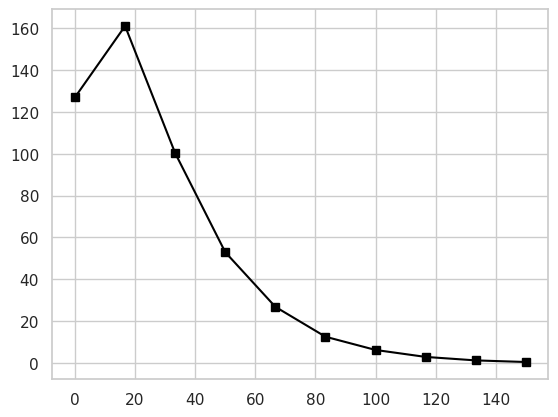

In [48]:
plt.plot(report_times,ave_I_rand,color="black",marker="s")

In [49]:
ave_I_data,ave_R_data,l_R_data = run_SIR_epidemics(G_data,tau,gamma,rho,tmax,transmission_weigth,count,report_times)

In [50]:
ave_I_gen,ave_R_gen,l_R_gen = run_SIR_epidemics(G_generated,tau,gamma,rho,tmax,transmission_weigth,count,report_times)

In [51]:
np.mean(l_R_random)

740.945

In [52]:
np.mean(l_R_data)

766.36

In [53]:
np.mean(l_R_gen)

743.51

TtestResult(statistic=3.2571965579306523, pvalue=0.0012216755203857432, df=398.0)
TtestResult(statistic=2.9846042118603435, pvalue=0.00301461915214306, df=398.0)
TtestResult(statistic=-0.3309968985841689, pvalue=0.7408210216555886, df=398.0)


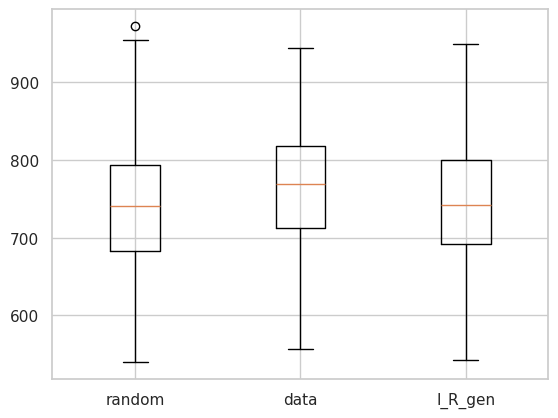

In [54]:
plt.boxplot([l_R_random,l_R_data,l_R_gen],labels=["random","data","l_R_gen"])
print(ttest_ind(l_R_data,l_R_random,equal_var=True))
print(ttest_ind(l_R_data,l_R_gen,equal_var=True))
print(ttest_ind(l_R_random,l_R_gen,equal_var=True))

In [55]:
proba_R_data = np.array(l_R_data)/np.sum(l_R_data)
proba_R_random = np.array(l_R_random)/np.sum(l_R_random)
proba_R_gen = np.array(l_R_gen)/np.sum(l_R_gen)
print("random KL",entropy(proba_R_data,proba_R_random))
print("gen KL",entropy(proba_R_data,proba_R_gen))

random KL 0.009610434295308348
gen KL 0.009897466343760902


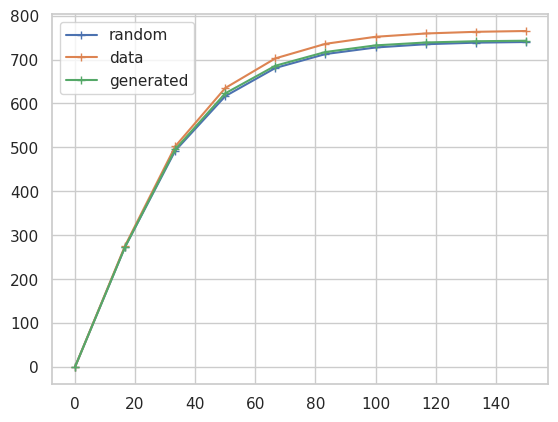

In [56]:
plt.plot(report_times,ave_R_rand,label="random",marker="+")
plt.plot(report_times,ave_R_data,label="data",marker="+")
plt.plot(report_times,ave_R_gen,label="generated",marker="+")
plt.legend()
plt.show()